In [1]:
import pandas as pd

from astropy.io import fits
from astropy.table import Table

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 18.0,
    "axes.labelsize": 18.0,
    "axes.titlesize": 18.0,
    "xtick.labelsize": 18.0,
    "ytick.labelsize": 18.0,
    "legend.fontsize": "medium",
    "legend.title_fontsize": 18.0,
    "figure.dpi": 72.0,
    "figure.figsize": (8.0, 6.0),
})

In [2]:
# Define the color map
morphology_colors = {
    30 : 'black',           # TFY1 to classify (30)
    20 : 'sienna',          # Ellipticals (20)
     0 :  'orchid',         # Lenticulars (0)
    -5 : 'cornflowerblue',  # Irregulars (-5)
    10 : 'limegreen',       # Spirals (10)
}

# Data

In [3]:
hdul = fits.open('fig5_data.fits')

umap_init = Table(hdul[1].data)
umap_pred = Table(hdul[2].data)

hdul.close()

# Initial UMAP

In [4]:
spirals = umap_init['Main_Type'] == 10

irregulars = umap_init['Main_Type'] == -5

lenticulars = umap_init['Main_Type'] == 0

ellipticals = umap_init['Main_Type'] == 20

unknown = umap_init['Main_Type'] == 30

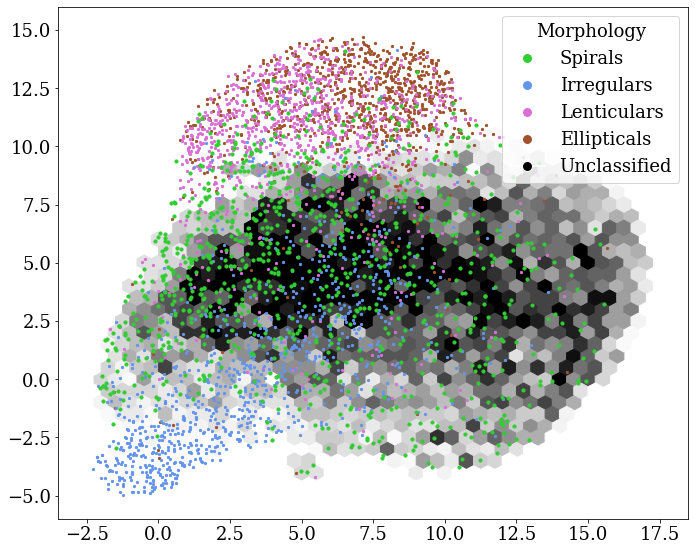

In [5]:
plt.figure(figsize=(10, 8), tight_layout=True)

plt.hexbin(umap_init['umap_x'][unknown], umap_init['umap_y'][unknown], 
           cmap='Grays', 
           mincnt=1, 
           gridsize=(40,20), 
           extent=(-2.5, 17.5, -5, 15), 
           vmax=20)

plt.scatter(umap_init['umap_x'][ellipticals], umap_init['umap_y'][ellipticals], s=5, c=morphology_colors[20])
plt.scatter(umap_init['umap_x'][lenticulars], umap_init['umap_y'][lenticulars], s=5, c=morphology_colors[0])
plt.scatter(umap_init['umap_x'][irregulars], umap_init['umap_y'][irregulars], s=5, c=morphology_colors[-5])
plt.scatter(umap_init['umap_x'][spirals], umap_init['umap_y'][spirals], s=10, c=morphology_colors[10])

legend_labels = {
    'Spirals': 'limegreen',
    'Irregulars': 'cornflowerblue',
    'Lenticulars': 'orchid',
    'Ellipticals': 'sienna',
    'Unclassified': 'black',
}

# Add legend to the plot
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) for label, color in legend_labels.items()]

plt.legend(handles=legend_handles, title='Morphology', loc='upper right');

# UMAP after first iteration

In [6]:
df_pred = umap_pred.to_pandas()

In [7]:
def choose_class(row):
    """Return the first non-'Other' prediction."""
    for col in pred_cols:
        if row[col] != "Other":
            return row[col]
    return "Other"

pred_cols = ["Spiral_Pred", "Elliptical_Pred", "Irregular_Pred", "Lenticular_Pred"]

df_pred["Class"] = df_pred.apply(choose_class, axis=1)

df_pred_only = df_pred[['SGA_ID', 'Class']]

In [8]:
# Merge predictions onto the UMAP dataframe
df = umap_init.to_pandas()
df_it1 = df.merge(df_pred_only, on="SGA_ID", how="left")

In [9]:
# map class to numeric type
class_to_code = {
    "Irregular": -5,
    "Lenticular": 0,
    "Spiral": 10,
    "Elliptical": 20,
    "Other": 30,   # still unclassified
}

df_it1["Pred_Main_Type"] = df_it1["Class"].map(class_to_code)

# determine unclassified original galaxies
is_unclassified_orig = (df_it1["Main_Type"] == 30) | (df_it1["Main_Type"].isna())

# keep original unless original was unclassified
df_it1["Main_Type_final"] = df_it1["Main_Type"]
df_it1.loc[is_unclassified_orig, "Main_Type_final"] = df_it1.loc[is_unclassified_orig, "Pred_Main_Type"]

df_it1["color"] = df_it1["Main_Type_final"].map(morphology_colors)

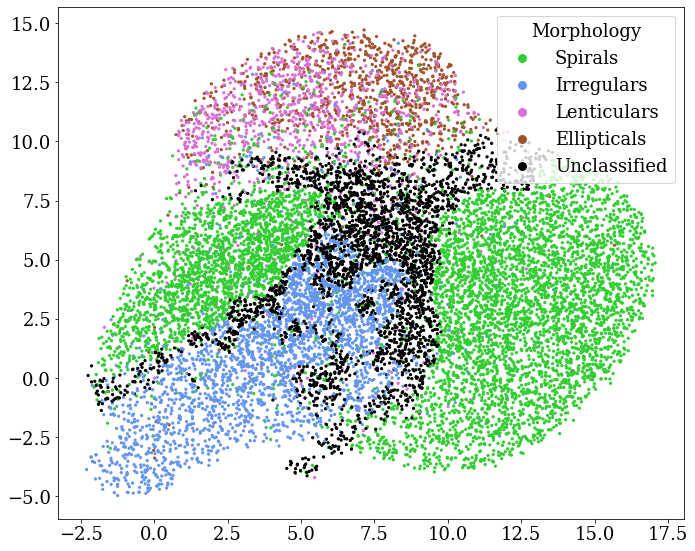

In [10]:
plt.figure(figsize=(10,8), tight_layout=True)

plt.scatter(df_it1["umap_x"], df_it1["umap_y"], s=5, c=df_it1["color"])

# Add legend to the plot
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) for label, color in legend_labels.items()]
plt.legend(handles=legend_handles, title='Morphology', loc='upper right');